In [5]:
#1 KM DATA
###########################################################################################

#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
res='1km'

In [6]:
# #250 M DATA
# ###########################################################################################

# #Loading in Packages and Data

# #Importing Packages
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.ticker as ticker
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize
# from matplotlib.ticker import MaxNLocator
# from matplotlib.ticker import ScalarFormatter
# import matplotlib.gridspec as gridspec
# import xarray as xr
# import os; import time
# import pickle
# import h5py
# ###############################################################
# def coefs(coefficients,degree):
#     coef=coefficients
#     coefs=""
#     for n in range(degree, -1, -1):
#         string=f"({coefficients[len(coef)-(n+1)]:.1e})"
#         coefs+=string + f"x^{n}"
#         if n != 0:
#             coefs+=" + "
#     return coefs
# ###############################################################

# #Importing Model Data
# check=False
# dir='/home/air673/koa_scratch/'

# netCDF=xr.open_dataset(dir+'cm1out.nc') #***
# res='250m'

In [7]:
#DEFINING FUNCTIONS
################################################################################

In [8]:
def minmax_surface_val_2D(var):
    if len(netCDF[var].dims) != 3:
        raise ValueError("Data is not 2D + Time")
    print(f'working on {var}\n')
    
    t=0
    min_val=netCDF[var].isel(time=t).min(dim=['yh', 'xh']).item()
    max_val=netCDF[var].isel(time=t).max(dim=['yh', 'xh']).item()
    
    for t in np.arange(1,len(netCDF['time'])):
        if np.mod(t,50)==0: print(f'current time {t}')
    
        current_min=netCDF[var].isel(time=t).min(dim=['yh', 'xh']).item()
        current_max=netCDF[var].isel(time=t).max(dim=['yh', 'xh']).item()
        min_val=min(min_val,current_min)
        max_val=max(max_val,current_max)

    #RETURNING
    if var in ['qv']:
        min_val*=1000
        max_val*=1000
    return (min_val,max_val)

# minmax_surface_val_2D('qvflux')[0]

def minmax_surface_val_3D(var):
    if len(netCDF[var].dims) != 4:
        raise ValueError("Data is not 3D + Time")
    print(f'working on {var}\n')
    
    t=0
    min_val=netCDF[var].isel(time=t,zh=0).min(dim=['yh', 'xh']).item()
    max_val=netCDF[var].isel(time=t,zh=0).max(dim=['yh', 'xh']).item()
    
    for t in np.arange(1,len(netCDF['time'])):
        if np.mod(t,50)==0: print(f'current time {t}')
    
        current_min=netCDF[var].isel(time=t,zh=0).min(dim=['yh', 'xh']).item()
        current_max=netCDF[var].isel(time=t,zh=0).max(dim=['yh', 'xh']).item()
        min_val=min(min_val,current_min)
        max_val=max(max_val,current_max)

    #RETURNING
    if var in ['qv']:
        min_val*=1000
        max_val*=1000
    return (min_val,max_val)

# minmax_surface_val_3D('qv')[0]

######################################################
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Variable_Calculation/'
def get_theta_v(t):
    import h5py
    with h5py.File(dir2 + 'theta_v'+f'_{res}'+'.h5', 'r') as f:
        theta_v_data = f['theta_v'][t]
    return theta_v_data

def minmax_theta_v():
    # if len(array.shape) != 3:
        # raise ValueError("Data is not 2D + Time")
    print(f'working on theta_v\n')
    
    t=0
    array=get_theta_v(t)
    min_val=np.min(array[0])
    max_val=np.max(array[0])

    for t in np.arange(1,len(netCDF['time'])):
        if np.mod(t,50)==0: print(f'current time {t}')
        array=get_theta_v(t)
        current_min=np.min(array[0])
        current_max=np.max(array[0])

        min_val=min(min_val,current_min)
        max_val=max(max_val,current_max)
    
    return (min_val,max_val)

def get_MSE(t):
    import h5py
    with h5py.File(dir2 + 'MSE'+f'_{res}'+'.h5', 'r') as f:
        theta_v_data = f['MSE'][t]
    return theta_v_data

def minmax_MSE():
    # if len(array.shape) != 3:
        # raise ValueError("Data is not 2D + Time")
    print(f'working on mse\n')
    
    t=0
    array=get_MSE(t)
    min_val=np.min(array[0])
    max_val=np.max(array[0])

    for t in np.arange(1,len(netCDF['time'])):
        if np.mod(t,50)==0: print(f'current time {t}')
        array=get_MSE(t)
        current_min=np.min(array[0])
        current_max=np.max(array[0])

        min_val=min(min_val,current_min)
        max_val=max(max_val,current_max)
    
    return (min_val,max_val)

In [9]:
def load_vars(data,t):
    surface_qv_data=data['qv'].data[0]*1000
    surface_th_data=data['th'].data[0]
    surface_qvflux_data=data['qvflux'].data
    surface_thflux_data=data['thflux'].data

    import h5py
    theta_v_data=get_theta_v(t)[0]
    surface_mse_data=get_MSE(t)[0]

    return surface_qv_data,surface_th_data,theta_v_data,surface_qvflux_data,surface_thflux_data,surface_mse_data

In [10]:
#RUNNING ANIMATION
###############################################################

In [11]:
# Store vmin and vmax for each variable in a list of tuples
vmin_max_values = [
    minmax_surface_val_3D('qv'),  
    minmax_surface_val_3D('th'),  
    minmax_theta_v(), 
    minmax_surface_val_2D('qvflux'),  
    minmax_surface_val_2D('thflux'),  
    minmax_MSE()
]

working on qv

current time 50
current time 100
working on th

current time 50
current time 100
working on theta_v

current time 50
current time 100
working on qvflux

current time 50
current time 100
working on thflux

current time 50
current time 100
working on mse

current time 50
current time 100


In [12]:
#TIME 00:00:00 Function
#Gets the realtime for the current timestep
def get_time(t):
    init_day,init_hour,init_min=0,0,0
    times=netCDF['time'].values/(1e9 * 60); time_inc=times.astype(int)[1]-times.astype(int)[0]
    current_min=init_hour*60+init_min+time_inc*t;
    
    days = init_day + (current_min // (24 * 60))
    
    remain_min = (init_min+time_inc*t) % (24 * 60); 
    hours = (init_hour + (remain_min // 60)) % 24
    mins = remain_min % 60

    ##############################################
    days=str(days);hours=str(hours);mins=str(mins)
    if len(days)==1:days='0'+days
    if len(hours)==1:hours='0'+hours
    if len(mins)==1:mins='0'+mins
    ##############################################

    combo=days+":"+hours+":"+mins
    return(days,hours,mins),(combo)

In [30]:
#PLOTTING FUNCTION
def single_plot(fig, t, vmin_max_values):
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.1, wspace=-0.1)
    ax1 = fig.add_subplot(gs[0, 0]) #qv
    ax2 = fig.add_subplot(gs[0, 1]) #qv_flux
    ax3 = fig.add_subplot(gs[1,0]) #th
    ax4 = fig.add_subplot(gs[1, 1]) #th_flux
    ax5 = fig.add_subplot(gs[2,0]) #th_v
    ax6 = fig.add_subplot(gs[2,1]) #MSE

    # Extract vmin and vmax from the tuple list for each variable
    vmin_qv, vmax_qv = vmin_max_values[0]
    vmin_th, vmax_th = vmin_max_values[1]
    vmin_th_v, vmax_th_v = vmin_max_values[2]
    vmin_qvflux, vmax_qvflux = vmin_max_values[3]
    vmin_thflux, vmax_thflux = vmin_max_values[4]
    vmin_mse, vmax_mse = vmin_max_values[5]

    # Define the levels using linspace for each variable to ensure consistent color mapping
    qv_levels = np.linspace(vmin_qv, vmax_qv, 100)
    th_levels = np.linspace(vmin_th, vmax_th, 100)
    th_v_levels = np.linspace(vmin_th_v, vmax_th_v, 100)
    qvflux_levels = np.linspace(vmin_qvflux, vmax_qvflux, 100)
    thflux_levels = np.linspace(vmin_thflux, vmax_thflux, 100)
    mse_levels = np.linspace(vmin_mse, vmax_mse, 100)

    #Get the Variables for Current Timestep
    data=netCDF.isel(time=t)
    [surface_qv_data, surface_th_data, surface_th_v_data, surface_qvflux_data, surface_thflux_data, surface_mse_data]=load_vars(data,t)

    # Create contour plots with consistent levels for each variable
    cf1 = ax1.contourf(surface_qv_data, levels=qv_levels)
    ax1.set_title("Surface " + r"$q_v$" + f" -- Time {get_time(t)[1]}")

    cf2 = ax2.contourf(surface_qvflux_data, levels=qvflux_levels)
    ax2.set_title("Surface " + r"$q_v$" + " Flux")
    
    cf3 = ax3.contourf(surface_th_data, levels=th_levels)
    ax3.set_title("Surface " + r"$\theta$")

    cf4 = ax4.contourf(surface_thflux_data, levels=thflux_levels)
    ax4.set_title("Surface " + r"$\theta$" + " Flux")
    
    cf5 = ax5.contourf(surface_th_v_data, levels=th_v_levels)
    ax5.set_title("Surface " + r"$\theta_v$")

    cf6 = ax6.contourf(surface_mse_data, levels=mse_levels)
    ax6.set_title("Surface " + "MSE")
    
    # Add colorbars to each subplot
    fig.colorbar(cf1, ax=ax1,label=r'$g/kg$')
    fig.colorbar(cf2, ax=ax2,label=r'$g/g \: m/s$')
    fig.colorbar(cf3, ax=ax3,label=r'$T$')
    fig.colorbar(cf4, ax=ax4,label=r'$K \: m/s$')
    fig.colorbar(cf5, ax=ax5,label=r'$K$')
    fig.colorbar(cf6, ax=ax6,label=r'$g/kg$')

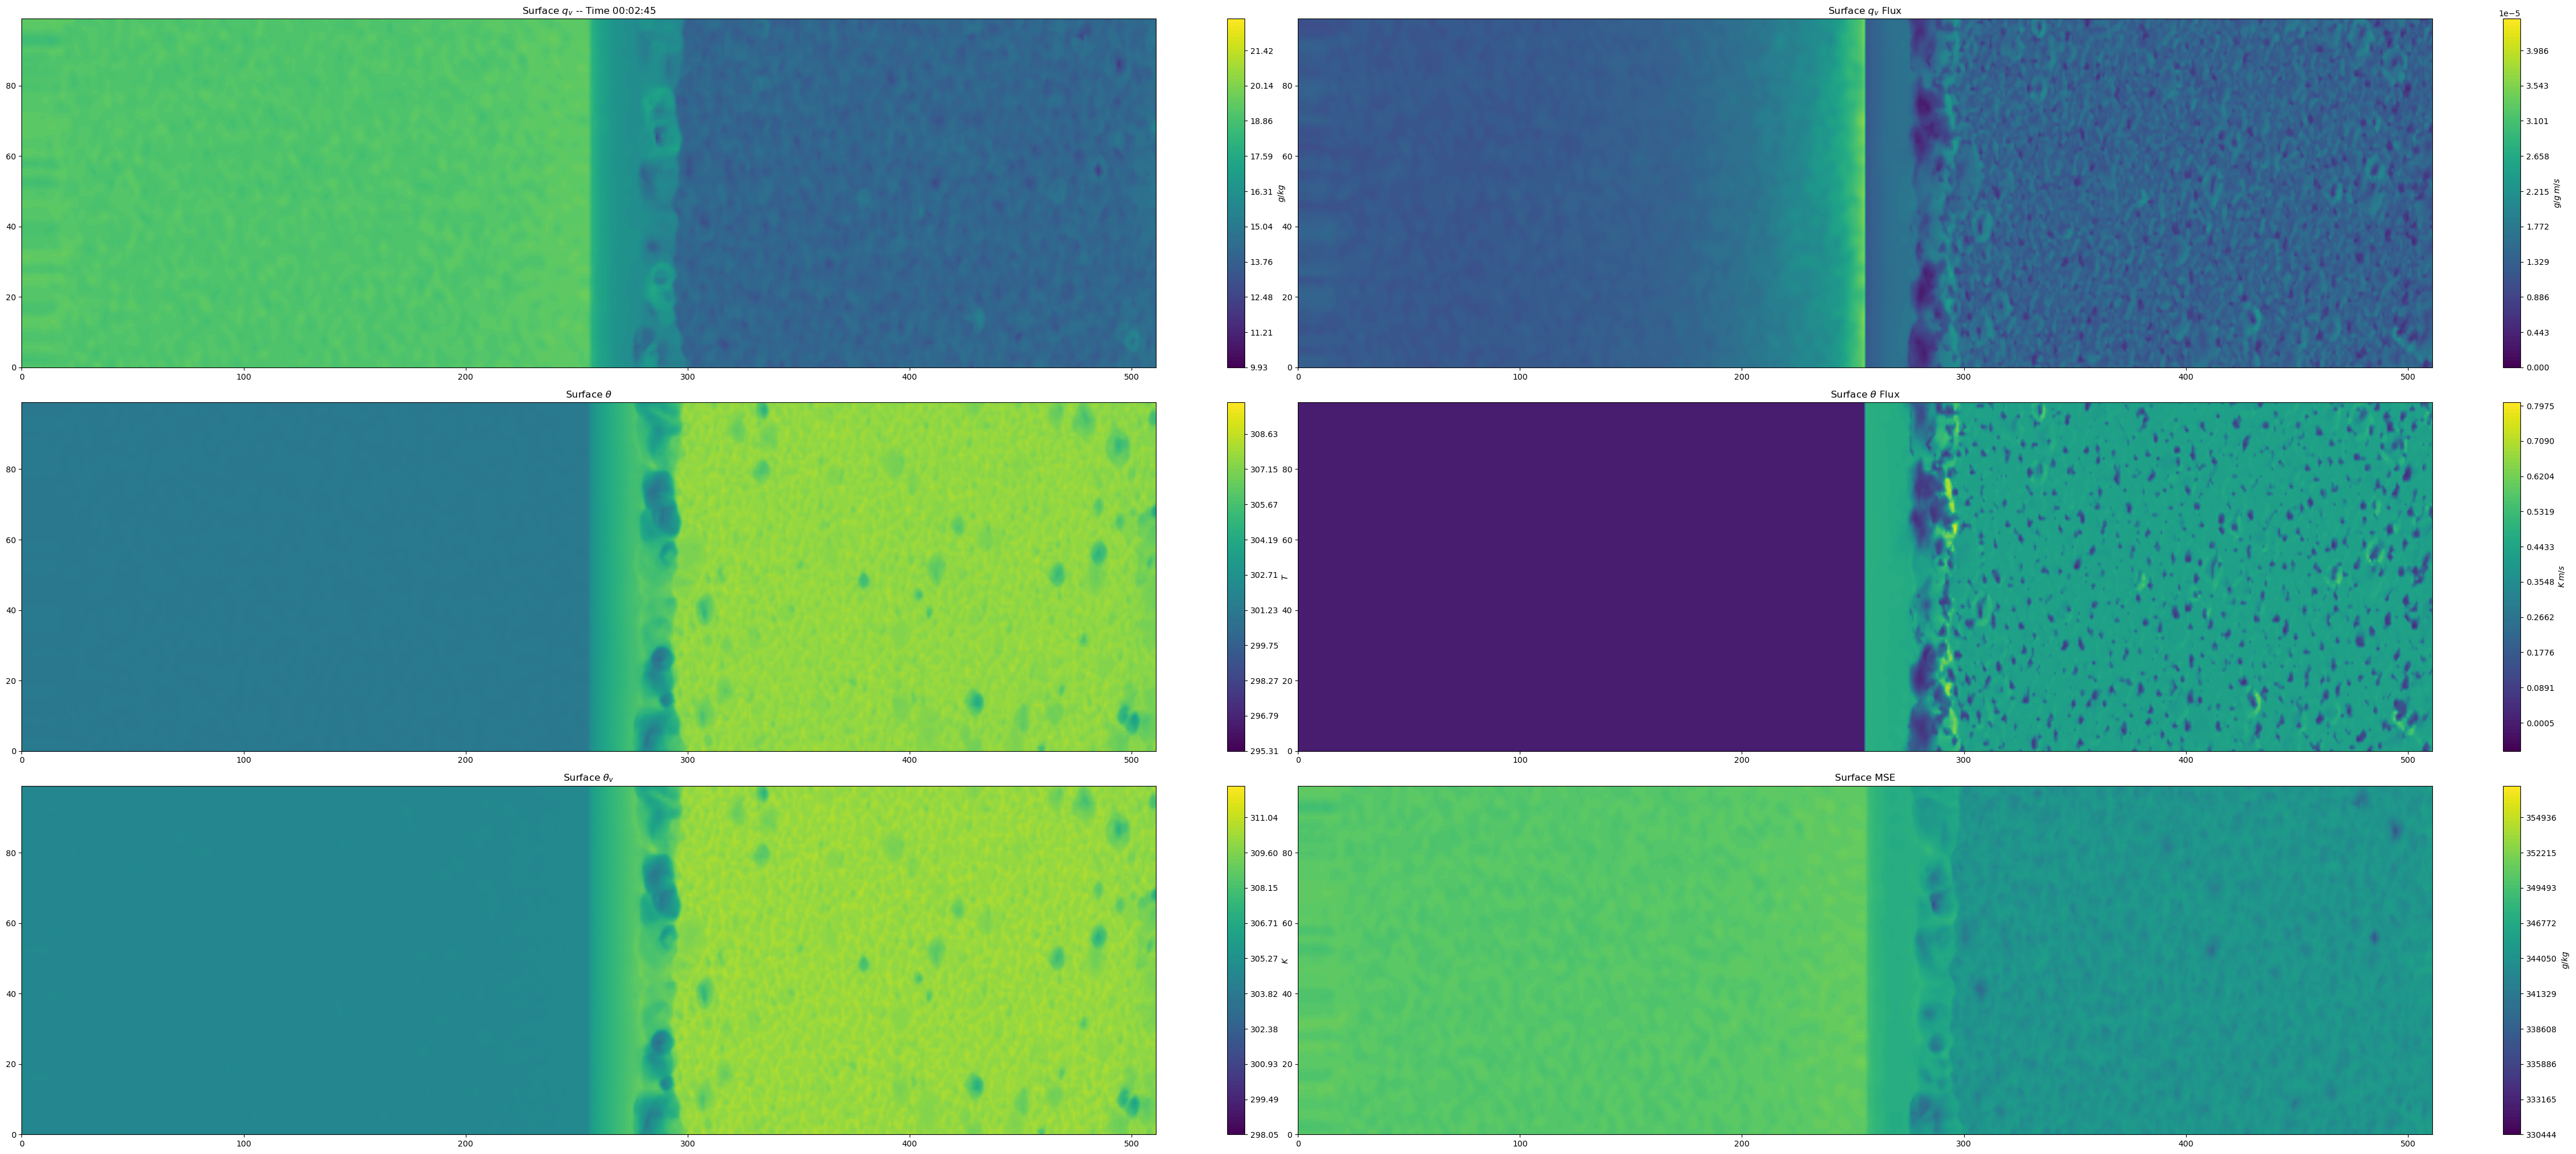

In [44]:
#TESTING SINGLE_PLOT FUNCTION

t=33
# fig = plt.figure(figsize=(35, 15))
fig = plt.figure(figsize=(60, 25))
single_plot(fig,t,vmin_max_values)

dir3='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
dir4 = dir3+'Animations/'
plt.savefig(dir4+'figure.jpg', format='jpg')

current t: 0
current t: 0
current t: 20
current t: 40
current t: 60
current t: 80
current t: 100
current t: 120


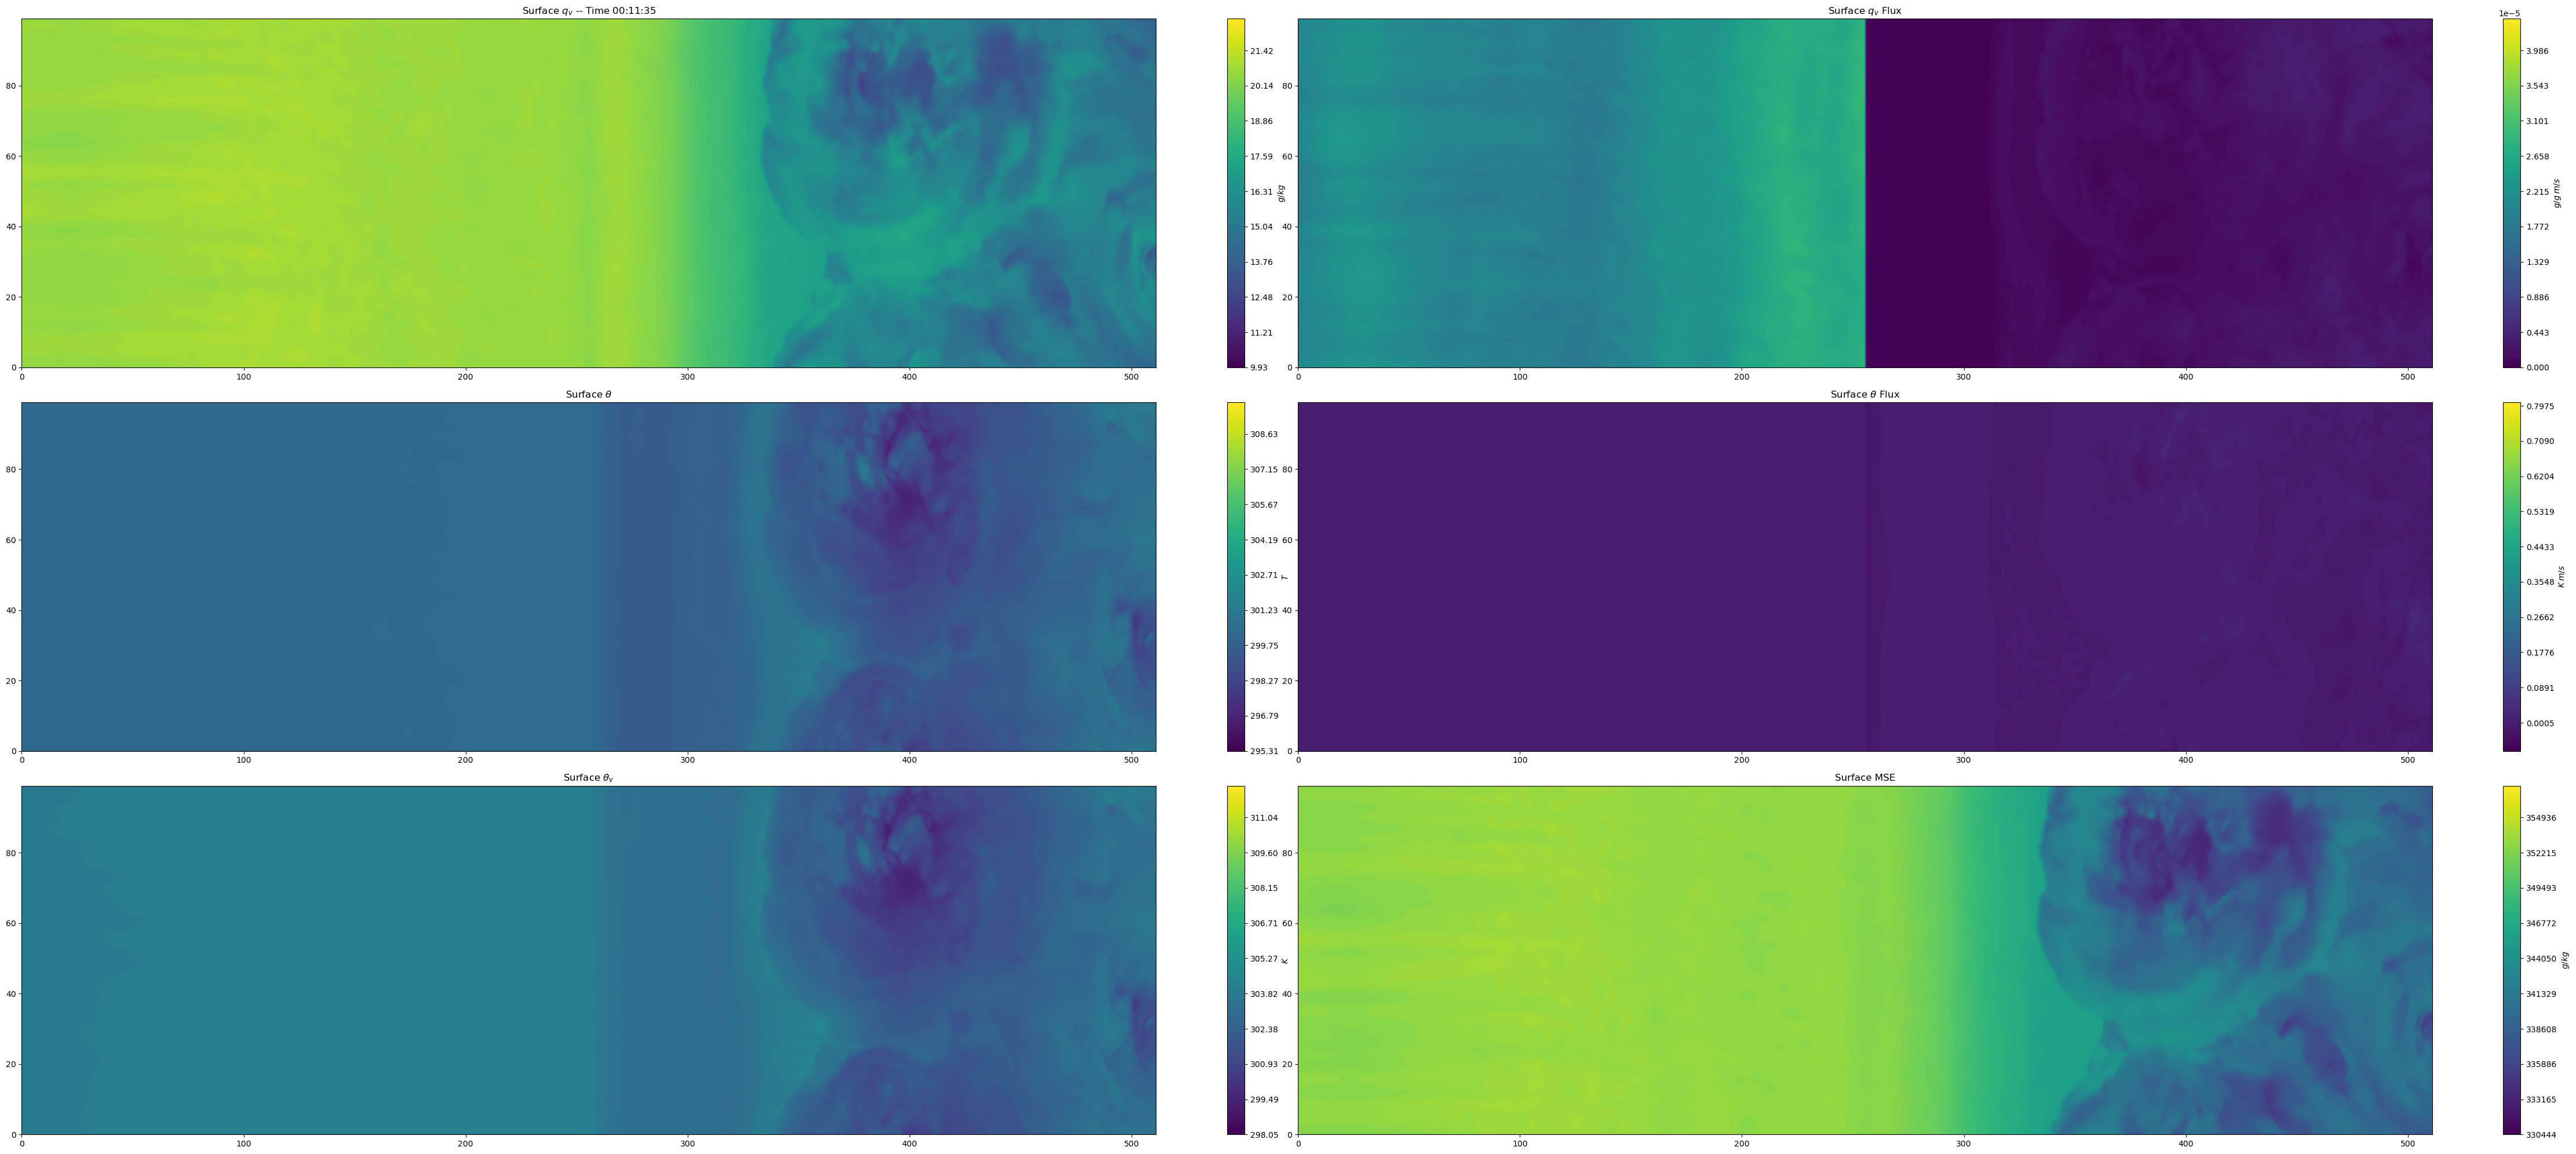

In [45]:
#ANIMATION FUNCTION
#MUST CREATE A SINGLE TIME PLOTTING FUNCTION TITLED single_plot(args) 

from matplotlib.animation import FuncAnimation, PillowWriter
def create_animation(start_t, end_t, output_file, vmin_max_values, fps=2):
    # Create a figure each time for the animation
    fig = plt.figure(figsize=(60, 25))

    # Define the update function for the animation
    def update(t):
        plt.clf()  # Clear the current figure
        if np.mod(t, 20) == 0:
            print(f'current t: {t}')
        single_plot(fig, t, vmin_max_values)  # Pass the figure and vmin_max_values to single_plot

    # Create the animation object
    ani = FuncAnimation(fig, update, frames=np.arange(start_t, end_t), repeat=False)

    # Save the animation as a GIF file using PillowWriter
    writer = PillowWriter(fps=fps) 
    ani.save(output_file, writer=writer)


# # RUNNING CODE
# output_filename = dir+'animations/QV_TH_animation_1km.gif'
# create_animation(start_t=33, end_t=35, output_file=output_filename, vmin_max_values=vmin_max_values)
# # create_animation(start_t=0, end_t=len(netCDF['time'])-1, output_file=output_filename, vmin_max_values=vmin_max_values)

res='1km'
# res='250m'

dir3='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
output_filename = dir3+'Animations/QV_TH_animation_'+res+'.gif'
# create_animation(start_t=0, end_t=3, output_file=output_filename, vmin_max_values=vmin_max_values) #TESTING
create_animation(start_t=0, end_t=len(netCDF['time'])-1, output_file=output_filename, vmin_max_values=vmin_max_values)

In [56]:
def convert_gif_to_mp4(input_file, output_file, fps,speed,bitrate='1000k'):
    from moviepy.editor import VideoFileClip, vfx
    # Load the GIF file
    gif_clip = VideoFileClip(input_file)

    # Set the desired framerate if provided
    if fps:
        gif_clip = gif_clip.set_fps(fps)
    if speed != 1.0:
        gif_clip = gif_clip.fx(vfx.speedx, speed)

    # Write the GIF as an MP4 file
    gif_clip.write_videofile(output_file, codec="libx264",bitrate=bitrate)



#RUNNING CONVERSION
# res='1km'
# input_filename = dir + 'Animations/QV_TH_animation_'+res+'.gif'
# output_filename = dir + 'Animations/QV_TH_animation_'+res+'.mp4'
# convert_gif_to_mp4(input_filename, output_filename, fps=None)  # Optional fps argument

res='1km'
res='250m'
input_filename = dir + 'Animations/QV_TH_animation_'+res+'.gif'
output_filename = dir + 'Animations/QV_TH_animation_'+res+'.mp4'
if res=='1km':
    convert_gif_to_mp4(input_filename, output_filename, fps=None,speed=2,bitrate='500k')  # Optional fps argument
elif res=='250m':
    convert_gif_to_mp4(input_filename, output_filename, fps=None,speed=10,bitrate='500k')  # Optional fps argument


                                                             
t:  56%|█████▌    | 39/70 [13:31<00:08,  3.62it/s, now=None]]
                                                             
t:  56%|█████▌    | 39/70 [13:31<00:08,  3.62it/s, now=None]]

Moviepy - Building video /mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Animations/QV_TH_animation_250m.mp4.
Moviepy - Writing video /mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Animations/QV_TH_animation_250m.mp4





t:   0%|          | 0/65 [00:00<?, ?it/s, now=None]

t:   5%|▍         | 3/65 [00:00<00:13,  4.48it/s, now=None]

t:   6%|▌         | 4/65 [00:01<00:22,  2.69it/s, now=None]

t:   8%|▊         | 5/65 [00:02<00:28,  2.10it/s, now=None]

t:   9%|▉         | 6/65 [00:02<00:31,  1.88it/s, now=None]

t:  11%|█         | 7/65 [00:03<00:34,  1.67it/s, now=None]

t:  12%|█▏        | 8/65 [00:04<00:36,  1.58it/s, now=None]

t:  14%|█▍        | 9/65 [00:04<00:36,  1.53it/s, now=None]

t:  15%|█▌        | 10/65 [00:05<00:36,  1.52it/s, now=None]

t:  17%|█▋        | 11/65 [00:06<00:35,  1.53it/s, now=None]

t:  18%|█▊        | 12/65 [00:06<00:34,  1.55it/s, now=None]

t:  20%|██        | 13/65 [00:07<00:34,  1.52it/s, now=None]

t:  22%|██▏       | 14/65 [00:08<00:33,  1.52it/s, now=None]

t:  23%|██▎       | 15/65 [00:08<00:33,  1.50it/s, now=None]

t:  25%|██▍       | 16/65 [00:09<00:32,  1.52it/s, now=None]

t:  26%|██▌       | 17/65 [00:10<00:31,  1.54it/s, now=None]

t:  28%|██▊       | 18

Moviepy - Done !
Moviepy - video ready /mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Animations/QV_TH_animation_250m.mp4
